# CSC221 Group Project

**Author:** HDung Rmah

**Partner:** Chandler Riley

## Project Description

This notebook collects product data from the DummyJSON Products REST API using a REST API request.

The collected information includes:

- Product Title
- Price
- Rating
- Stock
- Brand
- Category

The data is stored in a pandas DataFrame and exported as a CSV file for later data visualization and analysis.

In [1]:
import requests
import pandas as pd

## Fetch Data from the REST API

In [2]:


url = "https://dummyjson.com/products?limit=100"

response = requests.get(url)

data = response.json() 

## Create the DataFrame

In [3]:
products = []

for product in data["products"]:
    products.append({
        "Title": product.get("title", "N/A"),
        "Price": product.get("price", 0),
        "Rating": product.get("rating", 0),
        "Stock": product.get("stock", 0),
        "Brand": product.get("brand", "Unknown"),
        "Category": product.get("category", "Unknown")
    })

df = pd.DataFrame(products)

## Display the DataFrame

In [4]:
df.head(10) 

,Title,Price,Rating,Stock,Brand,Category
0,Essence Mascara Lash Princess,9.99,2.56,99,Essence,beauty
1,Eyeshadow Palette with Mirror,19.99,2.86,34,Glamour Beauty,beauty
2,Powder Canister,14.99,4.64,89,Velvet Touch,beauty
3,Red Lipstick,12.99,4.36,91,Chic Cosmetics,beauty
4,Red Nail Polish,8.99,4.32,79,Nail Couture,beauty
5,Calvin Klein CK One,49.99,4.37,29,Calvin Klein,fragrances
6,Chanel Coco Noir Eau De,129.99,4.26,58,Chanel,fragrances
7,Dior J'adore,89.99,3.80,98,Dior,fragrances
8,Dolce Shine Eau de,69.99,3.96,4,Dolce & Gabbana,fragrances
9,Gucci Bloom Eau de,79.99,2.74,91,Gucci,fragrances


## Save the Data to a CSV File

In [5]:
df.to_csv("CSC221-GP-data.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


## Part 2 - Data Visualization
### **Collaborator** Chandler Riley
### **Date** July 18th, 2026
The following visualizations analyze the product data collected from the DummyJSON Products REST API. These graphs help summarize the data and identify patterns that are not as easy to see in the table alone.

In [ ]:
df.info()

In [6]:
df.describe(include="all")

,Title,Price,Rating,Stock,Brand,Category
count,100,100.000000,100.000000,100.000000,100,100
unique,100,NaN,NaN,NaN,32,11
top,Essence Mascara Lash Princess,NaN,NaN,NaN,Unknown,kitchen-accessories
freq,1,NaN,NaN,NaN,62,30
mean,NaN,646.679000,3.851700,54.400000,NaN,NaN
std,NaN,2359.380341,0.755814,29.899495,NaN,NaN
min,NaN,0.790000,2.530000,2.000000,NaN,NaN
25%,NaN,5.990000,3.180000,30.500000,NaN,NaN
50%,NaN,14.990000,3.910000,58.500000,NaN,NaN
75%,NaN,82.490000,4.552500,82.000000,NaN,NaN


In [7]:
df.isna().sum()

Title       0
Price       0
Rating      0
Stock       0
Brand       0
Category    0
dtype: int64

## Visualization 1 – Average Product Price by Category
A horizontal bar chart was selected because it provides a clear comparison of the average product price across different categories. This makes it easy to identify which categories have the highest and lowest average prices.

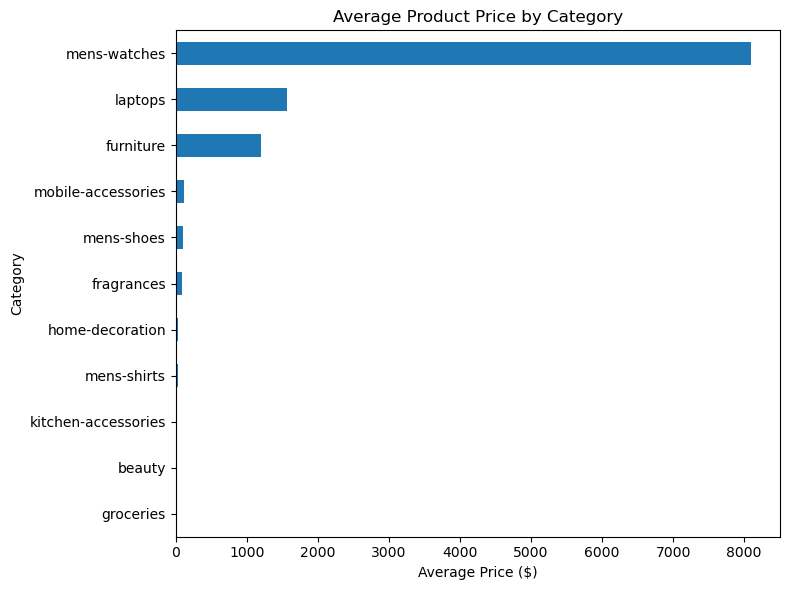

In [14]:
avg_price = df.groupby("Category")["Price"].mean().sort_values()

plt.figure(figsize=(8,6))
avg_price.plot(kind="barh")

plt.title("Average Product Price by Category")
plt.xlabel("Average Price ($)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## Visualization 2 – Price vs. Rating

A scatter plot was chosen because it is useful for showing the relationship between two numerical variables. This graph compares product prices with customer ratings to determine whether more expensive products tend to receive higher ratings.

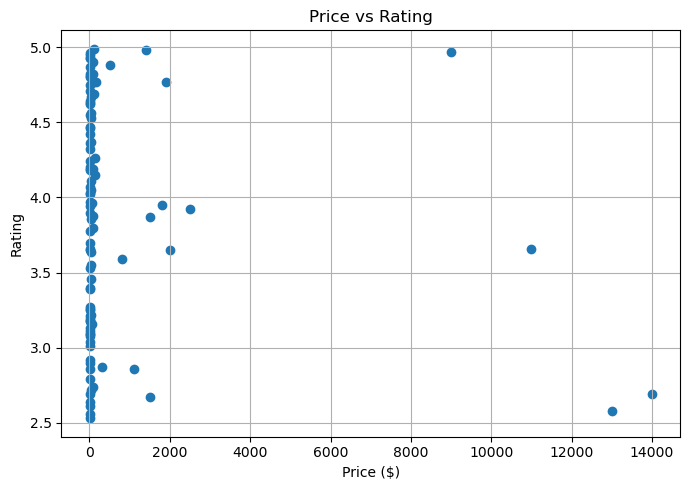

In [10]:
plt.figure(figsize=(7,5))

plt.scatter(df["Price"], df["Rating"])

plt.title("Price vs Rating")
plt.xlabel("Price ($)")
plt.ylabel("Rating")

plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
df.groupby("Category")["Price"].mean().sort_values(ascending=False)

Category
mens-watches           8098.323333
laptops                1559.990000
furniture              1199.990000
mobile-accessories      114.990000
mens-shoes              109.990000
fragrances               83.990000
home-decoration          38.990000
mens-shirts              27.590000
kitchen-accessories      17.690000
beauty                   13.390000
groceries                 5.467778
Name: Price, dtype: float64